# Regresión Lineal


### Nuevas librerías

Utilizaremos el módulo `scikit-learn` y `formulaic` de Python. Para instalarlos, correr:

In [ ]:
# !pip install scikit-learn
# !pip install formulaic

Importamos los módulos de siempre, las herramientas de modelos lineales y las medidas de desempeño del modelo de `scikit-learn`:

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import seaborn.objects as so

# Para plantear el modelo lineal
from formulaic import Formula   

# Herramientas de modelos lineales
from sklearn import linear_model  

# Medidas de desempeño
from sklearn.metrics import mean_squared_error, r2_score, root_mean_squared_error    

### Modelo de Regresión Lineal

Queremos utilizar un modelo lineal:
$$ Y = \beta_0 + \beta_1 X $$
para intentar predecir valores continuos.

### Visualización

Con lo que hemos visto las clases anteriores, visualizar la recta que mejor aproxima a los datos en el sentido de cuadrados mínimos es relativamente sencillo con `seaborn objects`, ya que `seaborn` calcula automáticamente los valores de $\beta_0$ y $\beta_1$.

Utilizaremos el dataset _tips_ de `seaborn` y analizaremos la relación entre lo que costó la comida y la cantidad de propina.

In [2]:
datos = sns.load_dataset('tips')
datos

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


Visualizamos los datos con `so.Plot` (repasar clase de visualización)

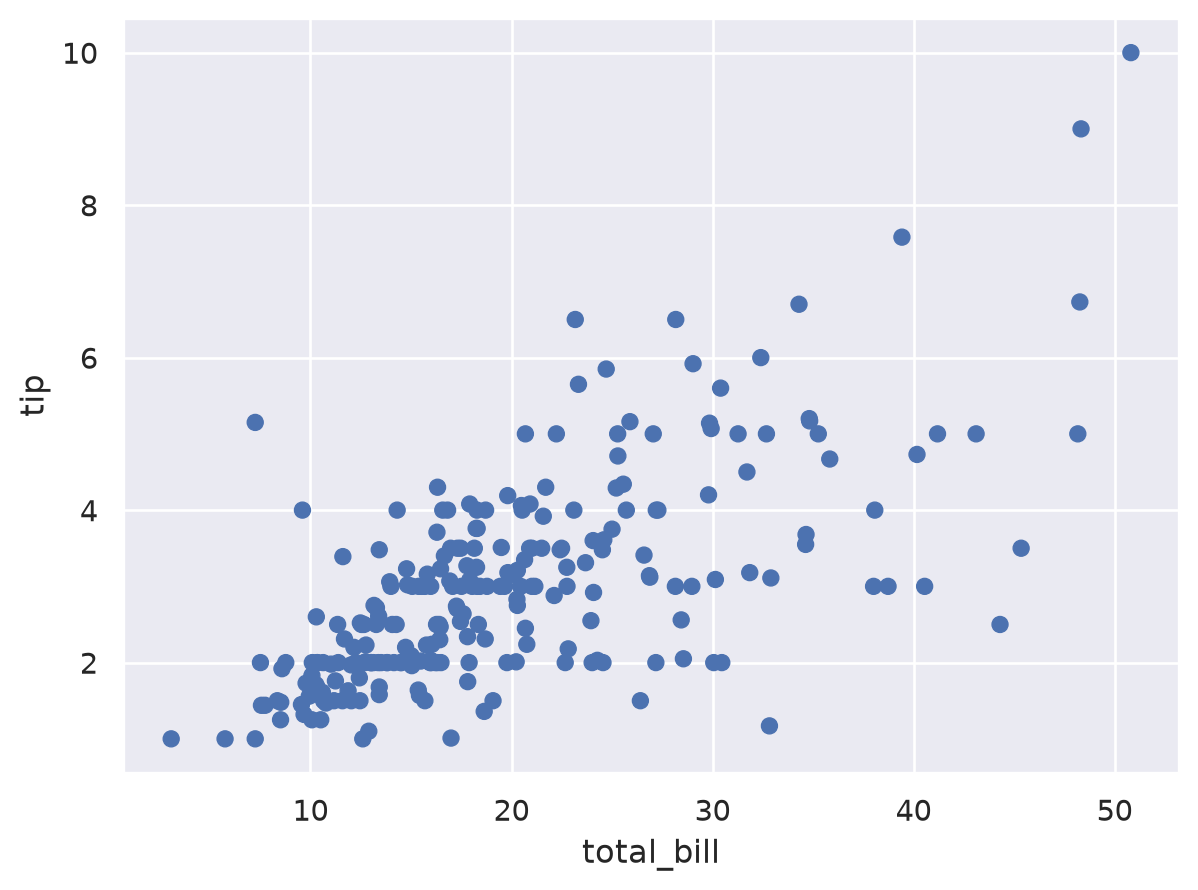

In [3]:
# Graficamos la relacion entre las variables 

(
    so.Plot(data=datos, x='total_bill', y='tip')
    .add(so.Dot())
)

Para visualizar la recta de la regresión, agregamos una línea al gráfico (`so.Line()`) junto a `so.PolyFit(1)`:

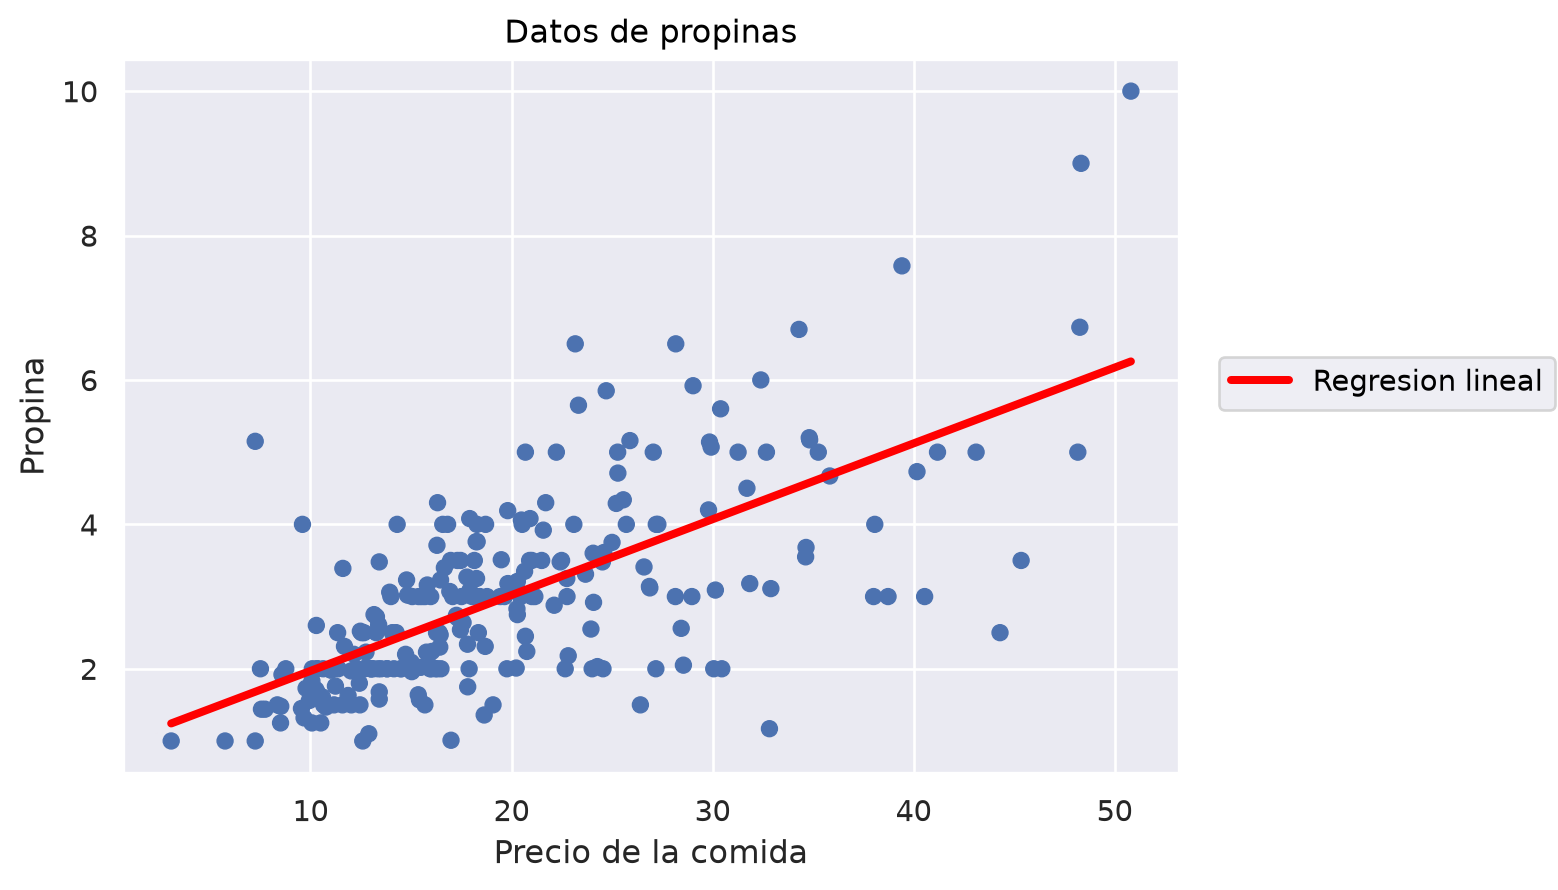

In [4]:
(
    so.Plot(data=datos, x='total_bill', y='tip')
    .add(so.Dot())
    .add(so.Line(color='red', linewidth=3), so.PolyFit(1), label='Regresion lineal')    # Agregamos una etiqueta para la leyenda del grafico
    .label(title='Datos de propinas', x='Precio de la comida', y='Propina')    # Agregamos la leyenda, un titulo y le cambiamos el nombre a los ejes
)

### Cálculo de coeficientes y predicciones

Desafortunamente, `seaborn` no nos devuelve los valores de $\beta_0$ y $\beta_1$, que son importantes en la interpretación del resultado.

Hemos visto que podemos calcular los coeficientes de la regresión lineal como:

 $$
 \begin{array}{rl}
      \hat{\beta}_1 = & \dfrac{\displaystyle\sum_{i=1}^n(x_i - \bar{x})(y_i - \bar{y})}{\displaystyle\sum_{i=1}^n(x_i - \bar{x})^2}  \\[1em]
      \hat{\beta}_0 = & \bar{y} - \hat{\beta}_1\bar{x}
 \end{array}
 $$

 pero también podemos utilizar `scikit-learn` y `formulaic`.

Como queremos predecir la propina según el precio de la comida usando una función lineal, la fórmula de Wilkinson es:
$$tip \sim total\_bill$$

In [5]:
# Obtenemos las matrices del modelo
y, X = Formula('tip ~ total_bill').get_model_matrix(datos)

In [6]:
# Inicializamos el modelo de regresión.
modelo = linear_model.LinearRegression(fit_intercept=False) # RECORDAR USAR fit_intercept = False

# Realiza el ajuste
modelo.fit(X, y)

# Para obtener los valores de beta_1 y beta_0 como valores numericos
beta = modelo.coef_
beta_0 = beta[0][0]
beta_1 = beta[0][1]
print('Beta_0: ', beta_0)
print('Beta_1: ', beta_1)

Beta_0:  0.9202696135546726
Beta_1:  0.10502451738435345


Entonces, la recta que mejor aproxima a los datos es (redondeando):
$$ Y = 0.92 + 0.105 X$$

Una interpretación que podemos darle a este resultado es que, por cada peso que costó la comida, se dejan de propina 0.105 pesos (o sea, alrededor de 10 centavos)

Con los valores de $\beta_0$ y $\beta_1$ podemos predecir cuanto será la propina según el valor de la comida. Supongamos que queremos predecir la propina que se deja por una cuenta \\$35. Utilizamos el método `predict()` del modelo.

<span style="color:red">**EL MÉTODO .predict() SOLO ADMITE DATAFRAMES (O MATRICES).**</span>

In [7]:
# Creamos un array con los valores a predecir
x_a_predecir = np.array([35])

# Creamos un DataFrame con los valores de X para los que queremos predecir
# Debe tener una columna de 1's que sea el Intercept (término independiente)
dataframe_a_predecir = pd.DataFrame({'Intercept': np.ones(x_a_predecir.shape), 'total_bill': x_a_predecir})

dataframe_a_predecir

,Intercept,total_bill
0,1.0,35


In [8]:
# Aplicamos la fórmula del modelo
modelo.predict(dataframe_a_predecir)

array([[4.59612772]])

In [9]:
# Para devolver directamente el numero agregamos .item()
modelo.predict(dataframe_a_predecir).item()

4.596127722007044

También podemos hacer directamente la cuenta porque ya sabemos cuanto valen $\beta_1$ y $\beta_0$:

In [10]:
beta_1 * 35 + beta_0

np.float64(4.596127722007044)

Podemos predecir varios valores de una:

In [11]:
# Creamos un array con los valores a predecir
x_a_predecir = np.array([35, 60])

# Creamos un DataFrame con los valores de X para los que queremos predecir
# Debe tener una columna de 1's que sea el Intercept (término independiente)
dataframe_a_predecir = pd.DataFrame({'Intercept': np.ones(x_a_predecir.shape), 'total_bill': x_a_predecir})

dataframe_a_predecir

,Intercept,total_bill
0,1.0,35
1,1.0,60


In [62]:
# Aplicamos la fórmula del modelo
modelo.predict(dataframe_a_predecir)

array([[4.59612772],
       [7.22174066]])

Si queremos calcular los valores predichos por el modelo $\hat{y}_i$ para todos nuestros $x_i$:

In [47]:
y_pred = modelo.predict(X)
display(y_pred)
type(y_pred)

array([[2.70463616],
       [2.00622312],
       [3.12683472],
       [3.40725019],
       [3.5028225 ],
       [3.57633966],
       [1.84133463],
       [3.74332864],
       [2.49983836],
       [2.47253198],
       [1.99887141],
       [4.6234341 ],
       [2.53974767],
       [2.85587147],
       [2.47778321],
       [3.1866987 ],
       [2.00517288],
       [2.631119  ],
       [2.70253567],
       [3.0890259 ],
       [2.80230897],
       [3.05121707],
       [2.57650625],
       [5.06033609],
       [3.00185555],
       [2.79075627],
       [2.32444741],
       [2.25303074],
       [3.19930164],
       [2.98400138],
       [1.92325375],
       [2.84746951],
       [2.50193885],
       [3.09322688],
       [2.78760553],
       [3.4471595 ],
       [2.63321949],
       [2.69833469],
       [2.88317784],
       [4.20438627],
       [2.60486287],
       [2.75399769],
       [2.38431139],
       [1.93690694],
       [4.11301494],
       [2.84116804],
       [3.25496464],
       [4.323

numpy.ndarray

El _.predict()_ devuelve una matriz que no puedo meter asi como sí en el seaborn para graficar. Al seaborn le puedo pasar (además del dataframe) un array o una serie. Lo que me conviene es hacer que el y_pred sea un array vector para poder graficarla con seaborn.

In [48]:
y_pred = y_pred[:,0]
y_pred

array([2.70463616, 2.00622312, 3.12683472, 3.40725019, 3.5028225 ,
       3.57633966, 1.84133463, 3.74332864, 2.49983836, 2.47253198,
       1.99887141, 4.6234341 , 2.53974767, 2.85587147, 2.47778321,
       3.1866987 , 2.00517288, 2.631119  , 2.70253567, 3.0890259 ,
       2.80230897, 3.05121707, 2.57650625, 5.06033609, 3.00185555,
       2.79075627, 2.32444741, 2.25303074, 3.19930164, 2.98400138,
       1.92325375, 2.84746951, 2.50193885, 3.09322688, 2.78760553,
       3.4471595 , 2.63321949, 2.69833469, 2.88317784, 4.20438627,
       2.60486287, 2.75399769, 2.38431139, 1.93690694, 4.11301494,
       2.84116804, 3.25496464, 4.32306398, 3.91871958, 2.81491191,
       2.23727706, 2.0009719 , 4.57617306, 1.96421332, 3.60469628,
       2.96719746, 4.91225152, 3.69396712, 2.10074519, 5.98980307,
       3.05121707, 2.3706582 , 2.0776398 , 2.84116804, 2.76765087,
       3.02916192, 2.64792292, 1.24269488, 3.0449156 , 2.49668762,
       2.18266431, 2.71303813, 3.74122815, 3.57528941, 2.46728

### Ejercicio

Utilizando el ya calculado `y_pred`, comparar en un mismo gráfico la recta de regresión obtenida con `seaborn objects` (en rojo y etiquetada "Regresion Seaborn") y la que resulta de utilizar `scikit-learn` (en azul y etiqueatada "Regresion Scikit"). El eje `y` debe tener la etiqueta "propina", el eje `x` la etiqueta "precio de la comida".

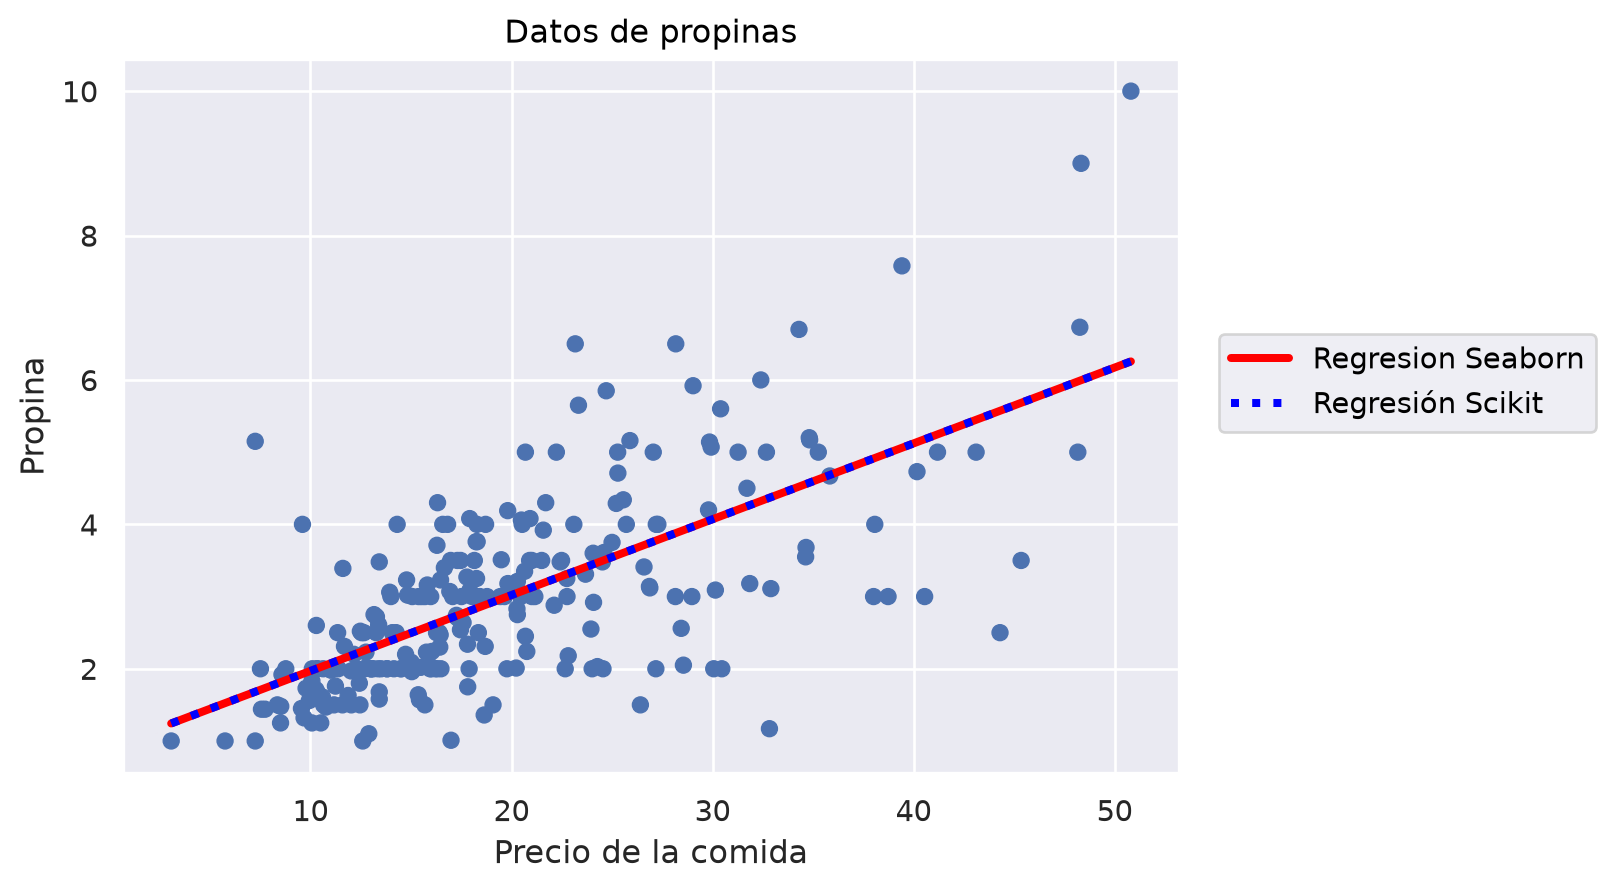

In [49]:
(
    so.Plot(data=datos, x='total_bill', y='tip')
    .add(so.Dot())
    .add(so.Line(color='red', linewidth = 3), so.PolyFit(1), label = 'Regresion Seaborn')
    .add(so.Line(color='blue', linewidth = 3, linestyle = ":"), y = y_pred, label = 'Regresión Scikit')   
    .label(title= 'Datos de propinas', x = 'Precio de la comida', y = 'Propina')    
)

### ¿Qué tan bueno es el modelo?

Finalmente, el bueno de `scikit-learn` nos calcula el coeficiente de determinación $R^ 2$: primero van los datos observados ( $y$ ) y luego los datos predichos ( $\hat{y}$ )

In [50]:
y_pred = modelo.predict(X)
r2_score(datos['tip'], y_pred)

0.45661658635167646

De manera análoga podemos calcular el error cuadrático medio (ECM):

In [51]:
mean_squared_error(datos['tip'], y_pred)

1.036019442011377

Y la raíz del error cuadrático medio:

In [52]:
root_mean_squared_error(datos['tip'], y_pred)

1.0178504025697377

Esto último podría interpretarse (informalmente) como que al usar el modelo para predecir cuánta propina dejo, en
promedio voy a cometer un error en el margen de $\pm 1.01785$ pesos.